In [ ]:
# This notebook calculates scattering cross sections and kinematics for
# T2 and H2 using the optical approximation.
#
# WARNING - I do not recommend to use it; the large angle behaviour of the
# optical approximation is importantly incorrect. This issue needs more
# theoretical attention before we can use these methods.

In [24]:
import numpy as np
import pandas as pd
import constants
import sampling
import pylab as plt
from scipy.interpolate import interp1d
import opticalapprox
%matplotlib inline


/var/folders/x8/m88g9m690wb3gf4t7ds85nzw0000gn/T/ipykernel_23839/2789827339.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support skipfooter; you can avoid this warning by specifying engine='python'.
  dat=pd.read_csv("./Data/OscStrengthH2.txt", skiprows=57,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)


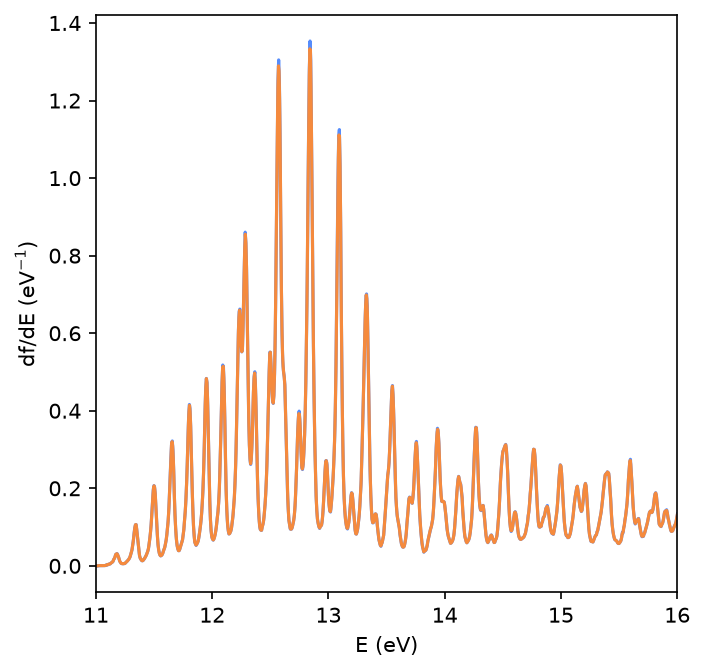

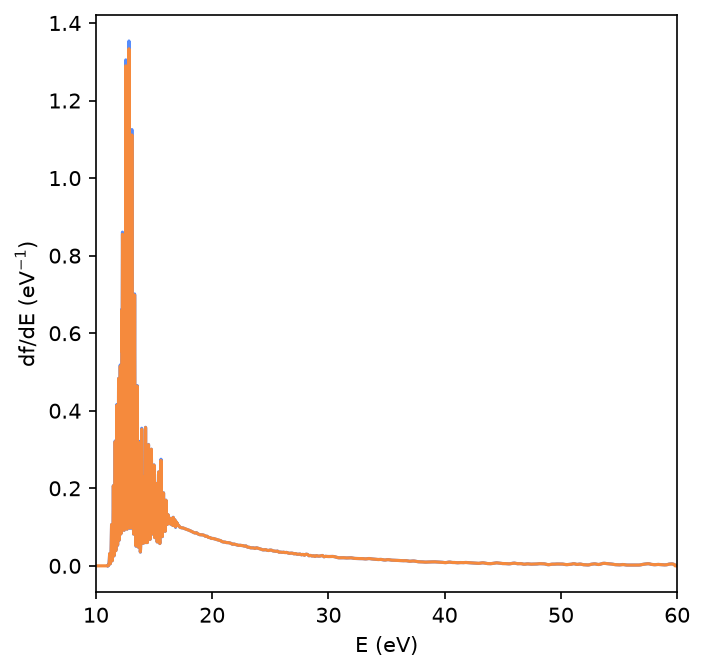

In [12]:

dat=pd.read_csv("./Data/OscStrengthH2.txt", skiprows=57,delimiter='\t',names=['E','dfdE'],dtype={'E':float,'dfdE':float},skipfooter=2)
OscStrH2=interp1d(dat['E'],dat['dfdE'],fill_value=0,bounds_error=False,kind='linear')

plt.figure(figsize=(5,5),dpi=150)
plt.plot(dat.E,dat.dfdE)
Es=np.linspace(10,60,10000)
plt.plot(Es,OscStrH2(Es))
plt.xlim(11,16)
plt.xlabel("E (eV)")
plt.ylabel(r"df/dE (eV$^{-1}$)")
plt.show()

plt.figure(figsize=(5,5),dpi=150)
plt.plot(dat.E,dat.dfdE)
Es=np.linspace(10,60,10000)
plt.plot(Es,OscStrH2(Es))
plt.xlim(10,60)
plt.xlabel("E (eV)")
plt.ylabel(r"df/dE (eV$^{-1}$)")
plt.show()

In [6]:
Ts=np.linspace(1e2,20e3,1000)
sigma_cont=[opticalapprox.sig_oscstrength(T,OscStrH2,constants.mT*2) for T in Ts]


Text(0, 0.5, '$\\sigma (m^2)$')

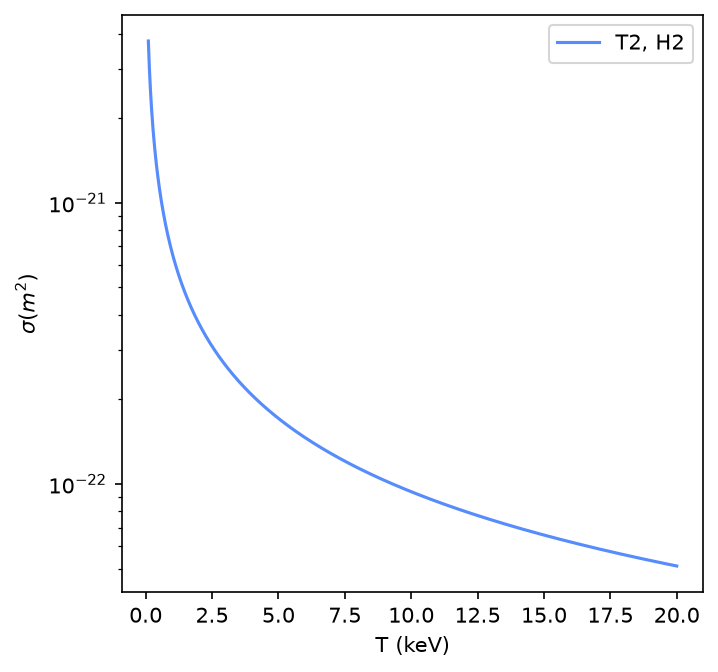

In [17]:
plt.figure(figsize=(5,5),dpi=150)
plt.plot(Ts/1000,sigma_cont,'-',label='T2, H2')
plt.legend(loc='upper right')
plt.semilogy()
plt.xlabel("T (keV)")
plt.ylabel(r"$\sigma (m^2)$")

In [8]:
dTs=[]
dThs=[]
for i in range(0,10000):
    dT,dTh=opticalapprox.SampleKinematics(20e3,OscStrH2,constants.mT*2)
    dTs.append(dT)
    dThs.append(dTh)


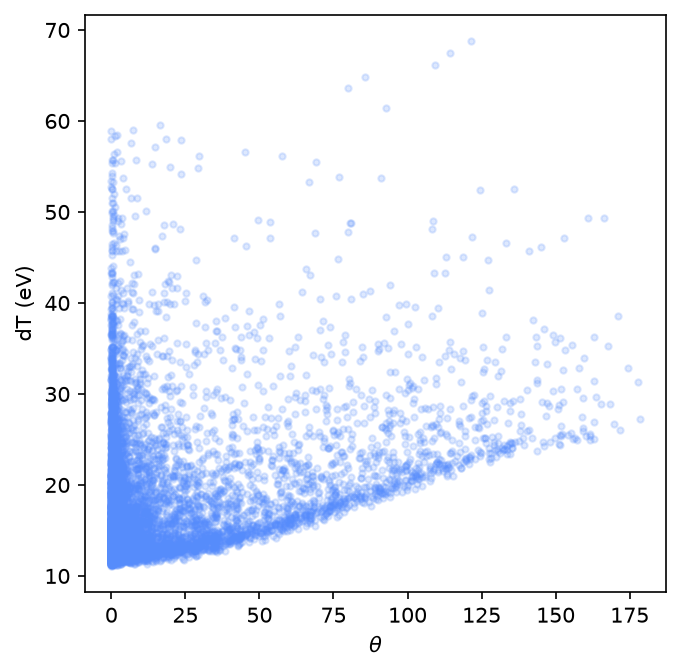

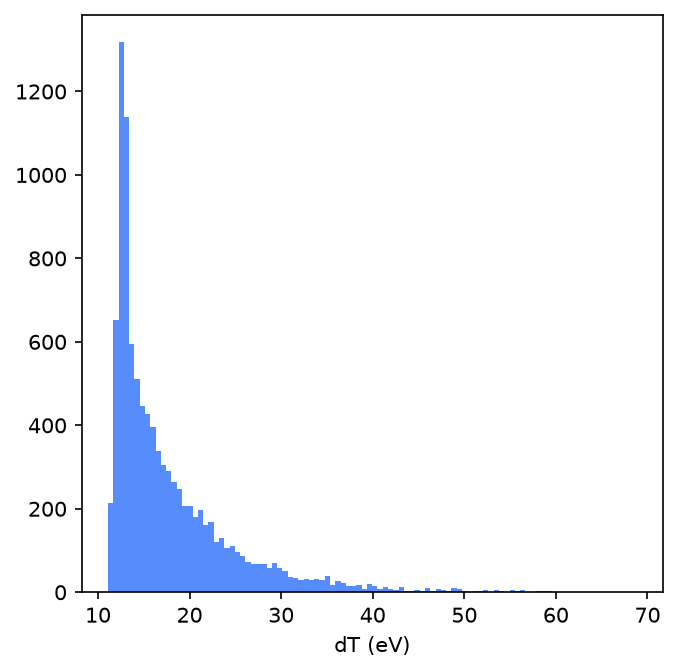

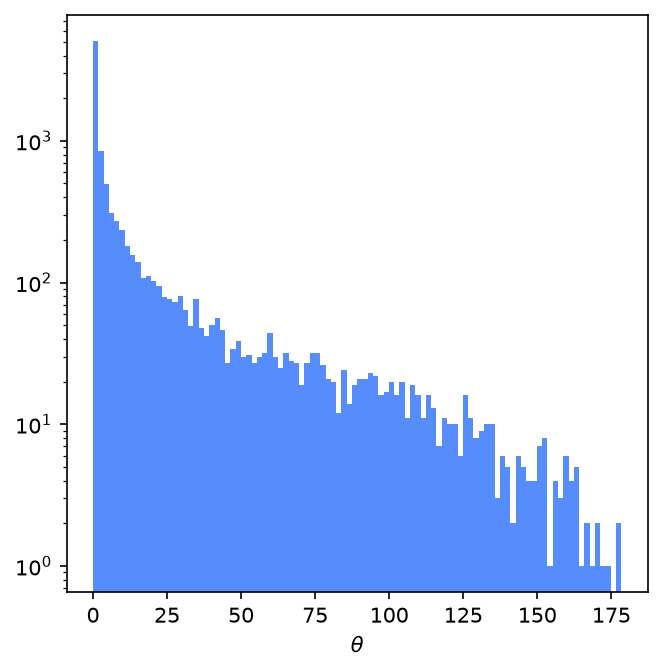

In [30]:
plt.figure(figsize=(5,5),dpi=150)
plt.plot(np.array(dThs)*180/np.pi,dTs,'.',alpha=0.2)
plt.ylabel("dT (eV)" )
plt.xlabel(r"$\theta$")
plt.show()
plt.figure(figsize=(5,5),dpi=150)
plt.hist(dTs,bins=100)
plt.xlabel("dT (eV)")
plt.show()
plt.figure(figsize=(5,5),dpi=150)
plt.hist(np.array(dThs)*180/np.pi,bins=100)
plt.xlabel(r"$\theta$")
plt.semilogy()
plt.show()

In [19]:
TotalCrossSections={}
KinematicsFunctions={}

TotalCrossSections['inelastic']=interp1d(Ts,sigma_cont)

def InelasticKinFunction(T):
    return opticalapprox.SampleKinematics(T,OscStrH2,constants.mT*2)
KinematicsFunctions['inelastic']=InelasticKinFunction

In [26]:
ElectronEnergy=18e3
Density0=20e3
#
for n in range(0,100):
    Distance, Theta, dT, CollisionTypeName = sampling.GetNextCollision(TotalCrossSections,KinematicsFunctions,T=ElectronEnergy,Density=Density0)

    print("Collision of type <" + str(CollisionTypeName) + "> after distance " + str(round(Distance,2)) + " m")
    print("   Energy loss dT = " + str(round(dT,3)) + " eV  angle  dTh = "+str(round(Theta*180/np.pi,2))+ " deg")
    print("   New electron E = " + str(ElectronEnergy))
    print()

    ElectronEnergy = ElectronEnergy - dT

Collision of type <inelastic> after distance 2.0437737427338112e+17 m
   Energy loss dT = 15.809 eV  angle  dTh = 0.79 deg
   New electron E = 18000.0

Collision of type <inelastic> after distance 2.978879306299711e+18 m
   Energy loss dT = 13.237 eV  angle  dTh = 0.56 deg
   New electron E = 17984.19140319262

Collision of type <inelastic> after distance 1.517240483810799e+18 m
   Energy loss dT = 13.525 eV  angle  dTh = 0.02 deg
   New electron E = 17970.95455429864

Collision of type <inelastic> after distance 5.465841120165898e+16 m
   Energy loss dT = 58.519 eV  angle  dTh = 4.58 deg
   New electron E = 17957.429208516132

Collision of type <inelastic> after distance 3.012905690261341e+17 m
   Energy loss dT = 17.528 eV  angle  dTh = 1.63 deg
   New electron E = 17898.90988298005

Collision of type <inelastic> after distance 3.192488524456945e+17 m
   Energy loss dT = 14.089 eV  angle  dTh = 2.91 deg
   New electron E = 17881.38202961621

Collision of type <inelastic> after distan